# Import and Filter Data

## From Challenge 2015 Dataset

In [1]:
import numpy as np
import pandas as pd

# Get Challenge 2015 dataset
with_ppg=[]
import os
for dirname, _, filenames in os.walk('/kaggle/input/challenge2015-reducing-false-arrhythmia/Challenge2015_csv/'):
    for filename in filenames:
        if(filename!="ALARMS"):
            if("PLETH" in pd.read_csv(dirname+filename).columns):
                with_ppg.append(filename[0:-4])

# Remove samples with asystole
df=pd.read_csv("/kaggle/input/challenge2015-reducing-false-arrhythmia/Challenge2015_csv/ALARMS", names=["Sample", "Label", "TrueAlarm"])
df_relevant=df.loc[df["Label"]!="Asystole"].copy()

# Only include samples with PPG
df_filtered=df_relevant.loc[df_relevant["Sample"].isin(with_ppg)].copy()

# Add path column
df_filtered["Path"]=["/kaggle/input/challenge2015-reducing-false-arrhythmia/Challenge2015_csv/"+x+".csv" for x in df_filtered["Sample"]]



## From PERform AFib Dataset

In [2]:
afib_paths=[]
healthy_paths=[]
afib_samples=[]
healthy_samples=[]

for dirname, _, filenames in os.walk('/kaggle/input/mimic-perform-af-dataset/mimic_perform_af_csv/mimic_perform_af_csv'):
    for filename in filenames:
        if("csv" in filename):
            afib_paths.append(dirname+"/"+filename)
            filename_split=filename.split("_")
            afib_samples.append(filename_split[2]+"_"+filename_split[3])

for dirname, _, filenames in os.walk('/kaggle/input/mimic-perform-af-dataset/mimic_perform_non_af_csv/mimic_perform_non_af_csv'):
    for filename in filenames:
        if("csv" in filename):
            healthy_paths.append(dirname+"/"+filename)
            filename_split=filename.split("_")
            healthy_samples.append(filename_split[2]+"_"+filename_split[3]+"_"+filename_split[4])

afib_df=pd.DataFrame({"Sample":afib_samples,
        "Label":19*["Atrial_Fibrillation"],
        "TrueAlarm":19*[True],
        "Path":afib_paths})

healthy_df=pd.DataFrame({"Sample":healthy_samples,
        "Label":16*["Healthy"],
        "TrueAlarm":16*[True],
        "Path":healthy_paths})

df_filtered=pd.concat([df_filtered, afib_df, healthy_df])

## Show Number of Waveforms Per Condition

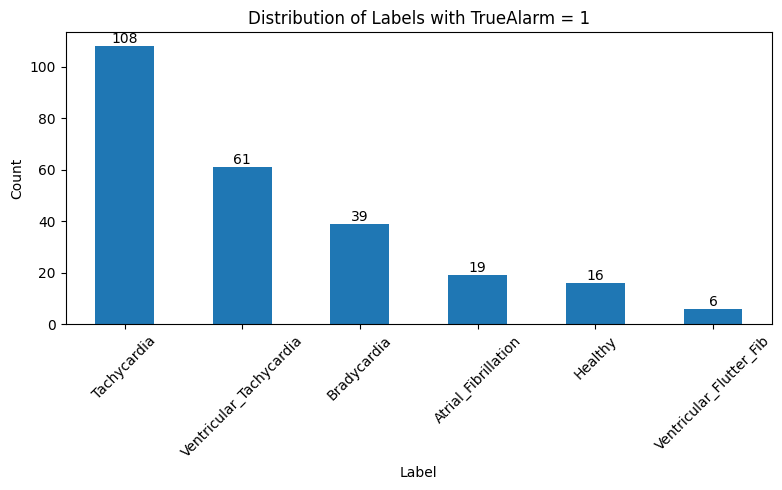

In [3]:
import matplotlib.pyplot as plt

# Count the occurrences of each label
label_counts = df_filtered.loc[df_filtered["TrueAlarm"] == 1, "Label"].value_counts()

# Plot as a bar plot
label_counts.plot(kind="bar", figsize=(8, 5))
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Distribution of Labels with TrueAlarm = 1")
plt.xticks(rotation=45)
plt.bar_label(plt.gca().containers[0])  # Add count labels on bars
plt.tight_layout()
plt.show()


## Quick-Access Functions

In [5]:
import scipy.signal as signal

# For downsampling 250 Hz to 125 Hz for consistency
def downsample(ecg_signal, original_fs=250, target_fs=125):
    if original_fs == target_fs:
        return ecg_signal  # No downsampling needed
    
    # Design a low-pass filter (FIR or IIR)
    nyquist = target_fs / 2  # Nyquist frequency for new sampling rate
    b, a = signal.butter(4, nyquist / (original_fs / 2), btype='low', analog=False)

    # Apply filter
    filtered_signal = signal.filtfilt(b, a, ecg_signal)

    # Downsample (take every 2nd sample)
    downsampled_signal = filtered_signal[::2]

    return downsampled_signal

def standardize(data):
    return ( data - np.mean(data) ) / np.std(data)

def getWaveform(label, index, sampleType, startPoint=0, duration=1024, trueAlarm=1):
    if(label=="Atrial_Fibrillation" or label=="Healthy"):
        return_signal=pd.read_csv(df_filtered.loc[(df_filtered["Label"]==label) & (df_filtered["TrueAlarm"]==trueAlarm), "Path"].values[index])[sampleType].values[startPoint:startPoint+int(duration/2)]
        pass
    else:
        if(sampleType=="ECG"):
            sampleType="II"
        elif(sampleType=="PPG"):
            sampleType="PLETH"
        try:
            return_signal = pd.read_csv(df_filtered.loc[(df_filtered["Label"]==label) & (df_filtered["TrueAlarm"]==trueAlarm), "Path"].values[index])[sampleType].values[startPoint:startPoint+duration]
        except:
            return_signal = pd.read_csv(df_filtered.loc[(df_filtered["Label"]==label) & (df_filtered["TrueAlarm"]==trueAlarm), "Path"].values[index])["V"].values[startPoint:startPoint+duration]
        
        return_signal=downsample(return_signal)
    return standardize(return_signal)

def getWaveforms(label, index, sampleType, duration=1024, trueAlarm=1):
    if(label=="Atrial_Fibrillation" or label=="Healthy"):
        fullWaveform = pd.read_csv(df_filtered.loc[(df_filtered["Label"]==label) & (df_filtered["TrueAlarm"]==trueAlarm), "Path"].values[index])[sampleType].values
        periodsList=[]
        for i in range(int(np.floor(len(fullWaveform)/duration))):
            periodsList.append(fullWaveform[i*duration:(i*duration)+duration])
    else:
        if(sampleType=="ECG"):
            sampleType="II"
        elif(sampleType=="PPG"):
            sampleType="PLETH"
        try:
            fullWaveform = downsample(pd.read_csv(df_filtered.loc[(df_filtered["Label"]==label) & (df_filtered["TrueAlarm"]==trueAlarm), "Path"].values[index])[sampleType].values)
        except:
            fullWaveform = downsample(pd.read_csv(df_filtered.loc[(df_filtered["Label"]==label) & (df_filtered["TrueAlarm"]==trueAlarm), "Path"].values[index])["V"].values)
        periodsList=[]
        for i in range(int(np.floor(len(fullWaveform)/duration))):
            periodsList.append(fullWaveform[i*duration:(i*duration)+duration])
    return periodsList

def get_num_waves(label, trueAlarm=1):
    return len(df_filtered.loc[(df_filtered["Label"]==label) & (df_filtered["TrueAlarm"]==trueAlarm)].index)

# Feature Extraction

## Sarah's PPG Feature Extractor (PPG)

In [6]:
def extract_ppg_features(ppg_signal, label, sampling_rate=125):
    """Extracts features from an 8-second PPG segment."""
    peaks, _ = find_peaks(ppg_signal, height=0.5)
    valleys, _ = find_peaks(-ppg_signal, height=-0.5)
    
    systolic_amplitude = max(ppg_signal[peaks]) - min(ppg_signal[valleys]) if len(peaks) > 0 and len(valleys) > 0 else 0
    diastolic_amplitude = min(ppg_signal[valleys]) if len(valleys) > 0 else 0
    
    pulse_intervals = np.diff(peaks) / sampling_rate if len(peaks) > 1 else [0]
    peak_to_peak_interval = np.mean(pulse_intervals) if len(pulse_intervals) > 0 else 0
    
    systolic_time = np.mean(np.diff(peaks)) / sampling_rate if len(peaks) > 1 else 0
    diastolic_time = np.mean(np.diff(valleys)) / sampling_rate if len(valleys) > 1 else 0
    
    systolic_area = trapezoidal_rule(ppg_signal[peaks]) if len(peaks) > 0 else 0
    diastolic_area = trapezoidal_rule(ppg_signal[valleys]) if len(valleys) > 0 else 0
    
    half_max = np.max(ppg_signal) / 2
    above_half = np.where(ppg_signal > half_max)[0]
    fwhm = (above_half[-1] - above_half[0]) / sampling_rate if len(above_half) > 1 else 0
    
    return {
        'Systolic Amplitude': systolic_amplitude,
        'Diastolic Amplitude': diastolic_amplitude,
        'Systolic Area': systolic_area,
        'Diastolic Area': diastolic_area,
        'Systolic Time': systolic_time,
        'Diastolic Time': diastolic_time,
        'Pulse Interval': np.mean(pulse_intervals),
        'Peak-to-Peak Interval': peak_to_peak_interval,
        'Full Width Half Maximum': fwhm,
        'Label': label
    }

def trapezoidal_rule(signal):
    """Computes the integral using the trapezoidal rule."""
    if len(signal) < 2:
        return 0  # Cannot integrate a single point
    return np.trapz(signal)

## Noor's Feature Extractor (ECG)

In [14]:
from scipy.signal import find_peaks
from scipy.fft import fft, fftfreq
import numpy as np
import matplotlib.pyplot as plt

# Sampling frequency
fs = 125

def getIntervals(points):
    intervals=[]
    for pi in range(len(points)-1):
            intervals.append(points[pi+1]-points[pi])
    return intervals

labels=[]
labels_passed=[]
groups=[]
groups_passed=[]

# ECG features
diff_median=[]
distance_median=[]
distance_std=[]
num_peaks=[]
num_valleys=[]
first_peak_freq=[]
second_peak_freq=[]
rr_median=[]
rr_std=[]
ss_median=[]
ss_std=[]

# PPG features
systolic_amp=[]
diastolic_amp=[]
systolic_area=[]
diastolic_area=[]
systolic_time=[]
diastolic_time=[]
pulse_interval=[]
pp_interval=[]
fwhm=[]

signals_ecg=[]
signals_ppg=[]

for label in df_filtered["Label"].unique():
    # Append true alarms
    for i in range(get_num_waves(label)):
        waveform_parts_ecg=getWaveforms(label, i, "ECG")
        waveform_parts_ppg=getWaveforms(label, i, "PPG")
        signals_ecg.extend(waveform_parts_ecg)
        signals_ppg.extend(waveform_parts_ppg)
        labels.extend(len(waveform_parts_ecg)*[label])
        groups.extend(len(waveform_parts_ecg)*[label+str(i)])
    # Append false alarms
    for i in range(get_num_waves(label, 0)):
        waveform_parts_ecg=getWaveforms(label, 0, "ECG", trueAlarm=0)
        waveform_parts_ppg=getWaveforms(label, 0, "PPG", trueAlarm=0)
        signals_ecg.extend(waveform_parts_ecg)
        signals_ppg.extend(waveform_parts_ppg)
        labels.extend(len(waveform_parts_ecg)*["Healthy"])
        groups.extend(len(waveform_parts_ecg)*["FalseAlarm"+str(i)])


for i in range(len(signals_ecg)):
    # Time-domain parameters
    N = len(signals_ecg[i])

    # Frequency-domain parameters
    yf = fft(signals_ecg[i])
    xf = fftfreq(N, 1 / fs)[:N // 2]
    yf_processed = 2.0 / N * np.abs(yf[:N // 2])

    # Detect peaks and valleys
    fft_peaks, _ = find_peaks(2.0/N * np.abs(yf[0:N//2]),
                          height=None, 
                          threshold=None, 
                          distance=None,
                          prominence=0.001,
                          width=0.75,
                          rel_height=0.5)
    
    fft_valleys, _ = find_peaks(-2.0/N * np.abs(yf[0:N//2]),
                          height=None, 
                          threshold=None, 
                          distance=None,
                          prominence=0.001,
                          width=1.5,
                          rel_height=0.5)
    # Time domain features
    td_peaks, _ = find_peaks(signals_ecg[i],
                          height=1, 
                          threshold=0.005, 
                          distance=0.3*fs,
                          prominence=0.2,
                          width=None,
                          rel_height=None)
    
    td_valleys, _ = find_peaks(-signals_ecg[i],
                          height=None, 
                          threshold=0.01, 
                          distance=0.3*fs,
                          prominence=0.4,
                          width=None,
                          rel_height=None)
    
    if(np.isnan(yf).any()): # Don't save anything if fft contains nan
        continue # go to next iteration
        
    diff_median.append(np.median(2.0/N * np.abs(yf[:N//2])[fft_peaks])-np.median(2.0/N * np.abs(yf[:N//2])[fft_valleys]))
    num_peaks.append(len(fft_peaks))
    num_valleys.append(len(fft_valleys))
    fft_intervals=getIntervals(2.0/N * np.abs(yf[:N//2])[fft_peaks]) # find intervals between every two peaks
    distance_median.append(np.median(fft_intervals))
    distance_std.append(np.std(fft_intervals))
    try:
        first_peak_freq.append(xf[fft_peaks[0]])
    except:
        first_peak_freq.append(0)
    try:
        second_peak_freq.append(xf[fft_peaks[1]])
    except:
        second_peak_freq.append(0)
    
    labels_passed.append(labels[i])
    groups_passed.append(groups[i])

    td_rr=getIntervals(td_peaks)
    td_ss=getIntervals(td_valleys)
    rr_median.append(np.median(td_rr))
    rr_std.append(np.std(td_rr))
    ss_median.append(np.median(td_ss))
    ss_std.append(np.std(td_ss))

    # PPG
    ppg_features=extract_ppg_features(signals_ppg[i], labels[i], sampling_rate=125)
    systolic_amp.append(ppg_features["Systolic Amplitude"])
    diastolic_amp.append(ppg_features["Diastolic Amplitude"])
    systolic_area.append(ppg_features["Systolic Area"])
    diastolic_area.append(ppg_features["Diastolic Area"])
    systolic_time.append(ppg_features["Systolic Time"])
    diastolic_time.append(ppg_features["Diastolic Time"])
    pulse_interval.append(ppg_features["Pulse Interval"])
    pp_interval.append(ppg_features["Peak-to-Peak Interval"])
    fwhm.append(ppg_features["Full Width Half Maximum"])

samples_df=pd.DataFrame({"Labels": labels_passed, "Groups": groups_passed, "diff_median":diff_median, 
                         "dist_median": distance_median, "dist_std": distance_std, "num_peaks":num_peaks, 
                         "num_valleys":num_valleys, "first_peak_freq":first_peak_freq, "second_peak_freq":second_peak_freq,
                         "rr_median": rr_median, "rr_std": rr_std, "ss_median": ss_median, "ss_std": ss_std,
                        "systolic_amp":systolic_amp, "diastolic_amp":diastolic_amp, "systolic_area":systolic_area,
                        "diastolic_area":diastolic_area, "systolic_time":systolic_time, "diastolic_time":diastolic_time,
                        "pulse_interval":pulse_interval, "pp_interval":pp_interval, "fwhm":fwhm})
samples_df=samples_df.dropna().reset_index(drop=True)
samples_df


,Labels,Groups,diff_median,dist_median,dist_std,num_peaks,num_valleys,first_peak_freq,second_peak_freq,rr_median,...,ss_std,systolic_amp,diastolic_amp,systolic_area,diastolic_area,systolic_time,diastolic_time,pulse_interval,pp_interval,fwhm
0,Ventricular_Tachycardia,Ventricular_Tachycardia0,18.248115,0.596140,95.397810,173,61,0.488281,1.342773,41.0,...,10.434069,0.000000,0.000000,297141.804875,0.000000,0.103077,0.000000,0.103077,0.103077,7.344
1,Ventricular_Tachycardia,Ventricular_Tachycardia0,11.671329,-0.115765,114.090057,112,75,0.854492,1.342773,49.0,...,12.476645,9190.259274,-2.885595,269116.566876,-15.975141,0.114000,0.035130,0.114000,0.114000,8.096
2,Ventricular_Tachycardia,Ventricular_Tachycardia0,14.258346,0.279073,118.969714,119,74,0.488281,0.854492,42.0,...,12.588575,0.000000,0.000000,290293.713241,0.000000,0.117091,0.000000,0.117091,0.117091,8.184
3,Ventricular_Tachycardia,Ventricular_Tachycardia0,7.505482,-0.757254,152.092651,124,77,0.366211,0.732422,49.0,...,12.557153,0.000000,0.000000,397210.971306,0.000000,0.093810,0.000000,0.093810,0.093810,7.600
4,Ventricular_Tachycardia,Ventricular_Tachycardia0,11.444011,0.138986,86.072669,133,82,0.732422,1.098633,42.0,...,12.850195,0.000000,0.000000,677768.021776,0.000000,0.052416,0.000000,0.052416,0.052416,5.472
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21347,Healthy,Healthy15,0.004485,0.000093,0.014653,55,45,0.244141,1.098633,77.5,...,32.252476,0.551320,0.253177,8.925709,5.406158,0.620667,0.463059,0.620667,0.620667,8.184
21348,Healthy,Healthy15,0.003656,-0.000303,0.009189,58,47,0.244141,0.732422,78.0,...,49.146041,0.539589,0.254154,8.814761,3.819648,0.623333,0.574769,0.623333,0.623333,8.000
21349,Healthy,Healthy15,0.005698,-0.000069,0.016457,59,44,0.244141,0.610352,77.0,...,23.271442,0.463343,0.242424,8.012219,4.888563,0.619333,0.475294,0.619333,0.619333,8.080
21350,Healthy,Healthy15,0.008470,-0.000208,0.009219,45,40,0.244141,0.488281,77.0,...,31.000806,0.611926,0.240469,9.342131,4.494135,0.617231,0.508267,0.617231,0.617231,8.184


## Plot Number of Samples Per Condition

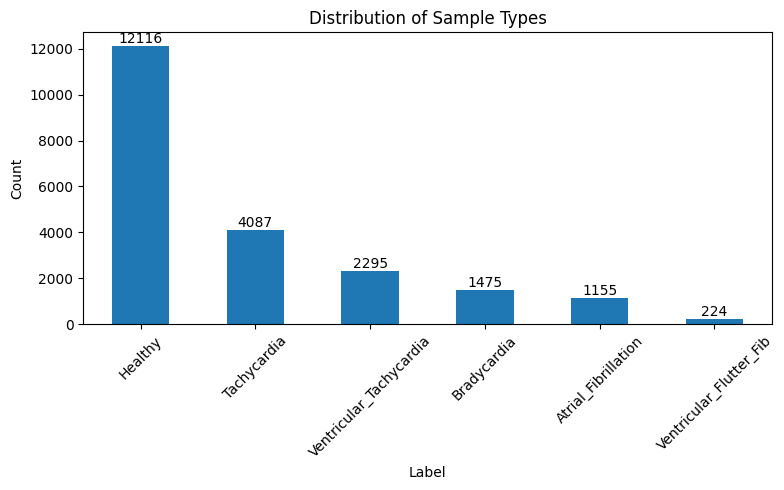

In [15]:
# Count the occurrences of each label
label_counts = samples_df["Labels"].value_counts()

# Plot as a bar plot
label_counts.plot(kind="bar", figsize=(8, 5))
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Distribution of Sample Types")
plt.xticks(rotation=45)
plt.bar_label(plt.gca().containers[0])  # Add count labels on bars
plt.tight_layout()
plt.show()


# Training: Combined Model


################################################################

STATUS REPORT:
Iteration 1 of 10 runs completed
Test_Score: 0.820, Best_Valid_Score: 0.820

################################################################
 


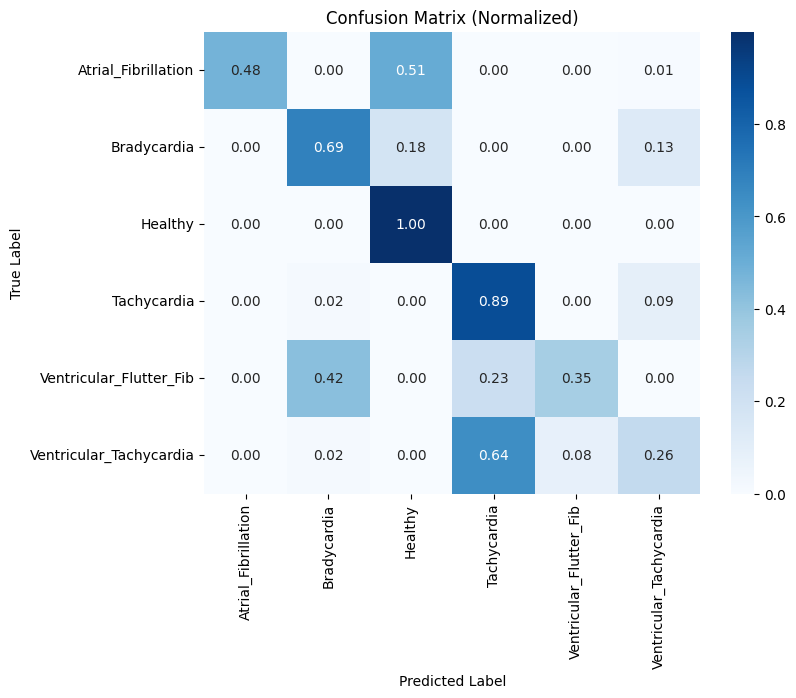


################################################################

STATUS REPORT:
Iteration 2 of 10 runs completed
Test_Score: 0.821, Best_Valid_Score: 0.821

################################################################
 


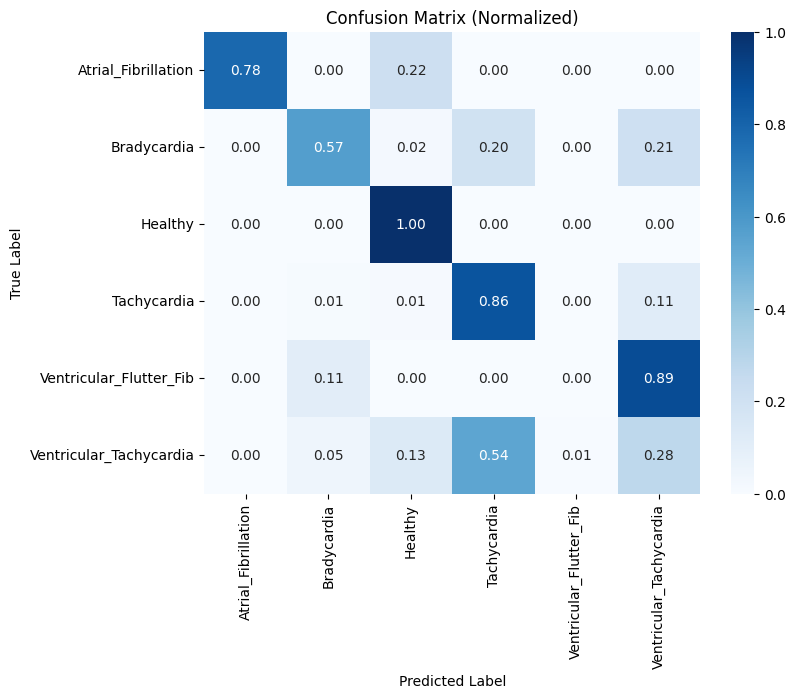


################################################################

STATUS REPORT:
Iteration 3 of 10 runs completed
Test_Score: 0.817, Best_Valid_Score: 0.821

################################################################
 


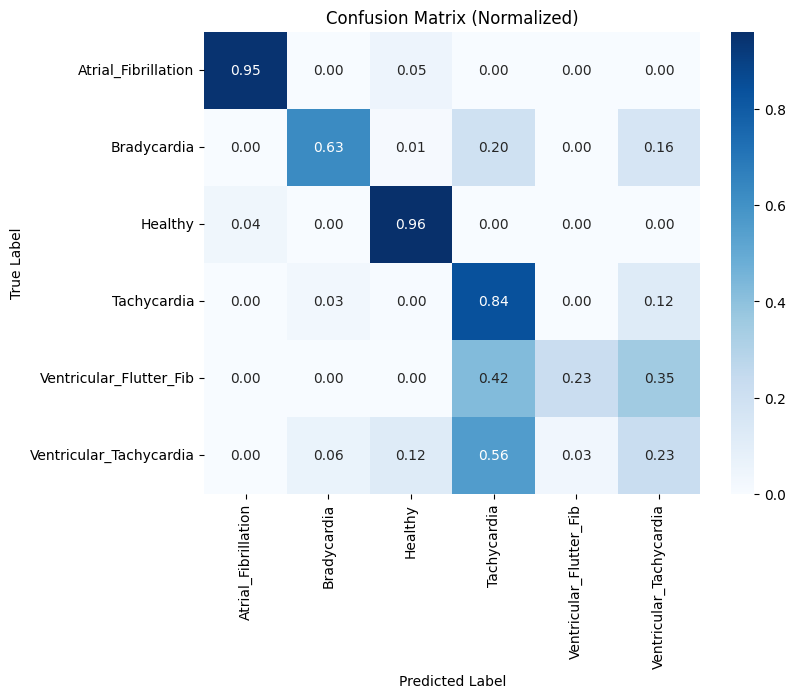


################################################################

STATUS REPORT:
Iteration 4 of 10 runs completed
Test_Score: 0.818, Best_Valid_Score: 0.821

################################################################
 


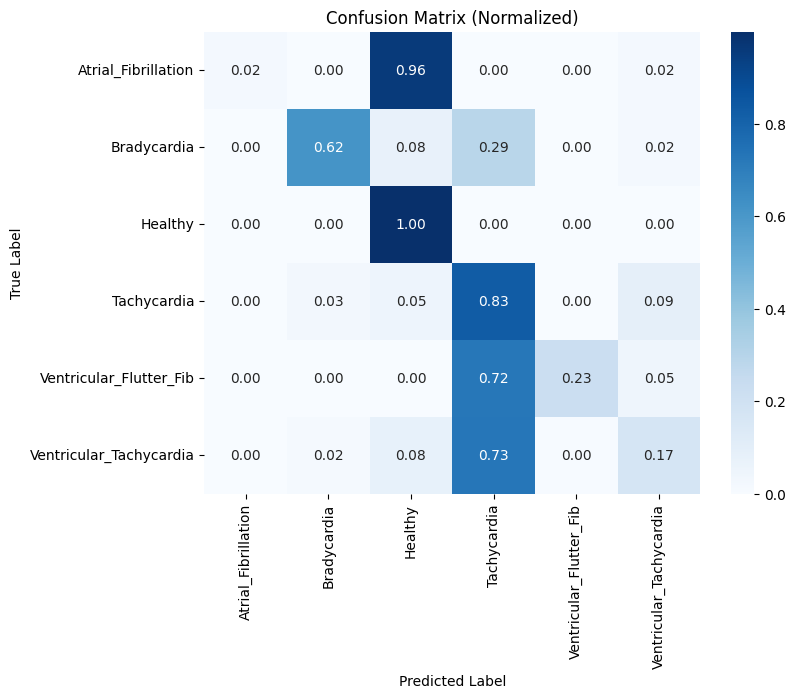


################################################################

STATUS REPORT:
Iteration 5 of 10 runs completed
Test_Score: 0.859, Best_Valid_Score: 0.859

################################################################
 


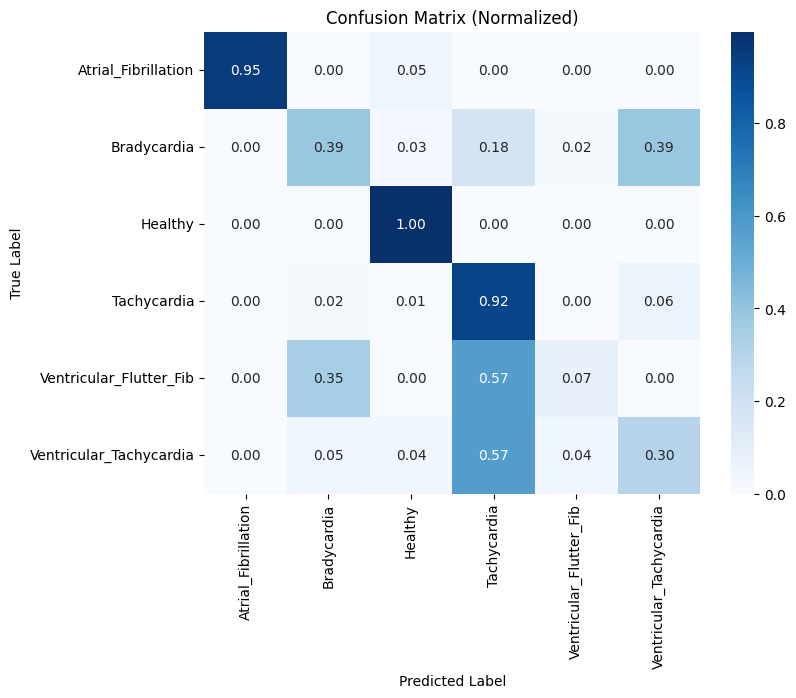


################################################################

STATUS REPORT:
Iteration 6 of 10 runs completed
Test_Score: 0.816, Best_Valid_Score: 0.859

################################################################
 


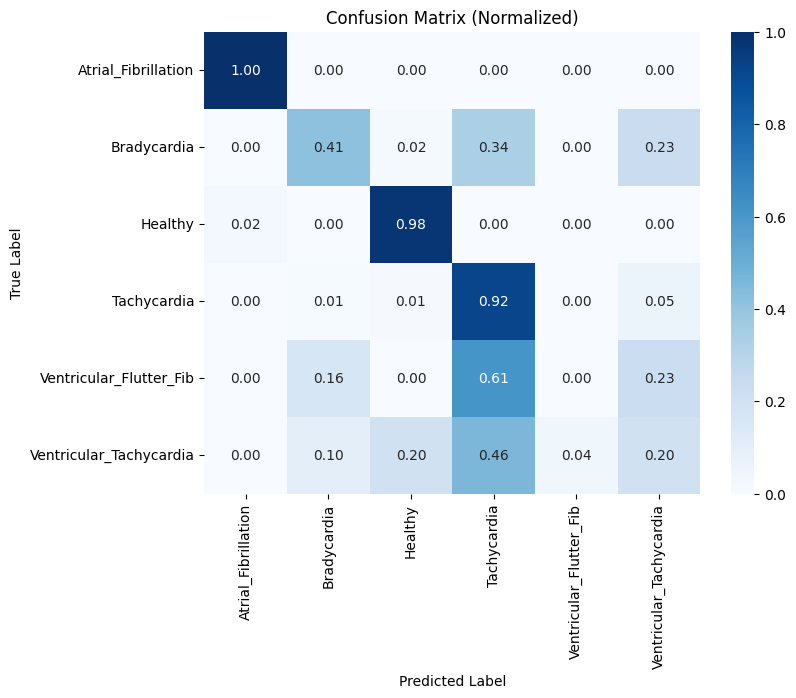


################################################################

STATUS REPORT:
Iteration 7 of 10 runs completed
Test_Score: 0.844, Best_Valid_Score: 0.859

################################################################
 


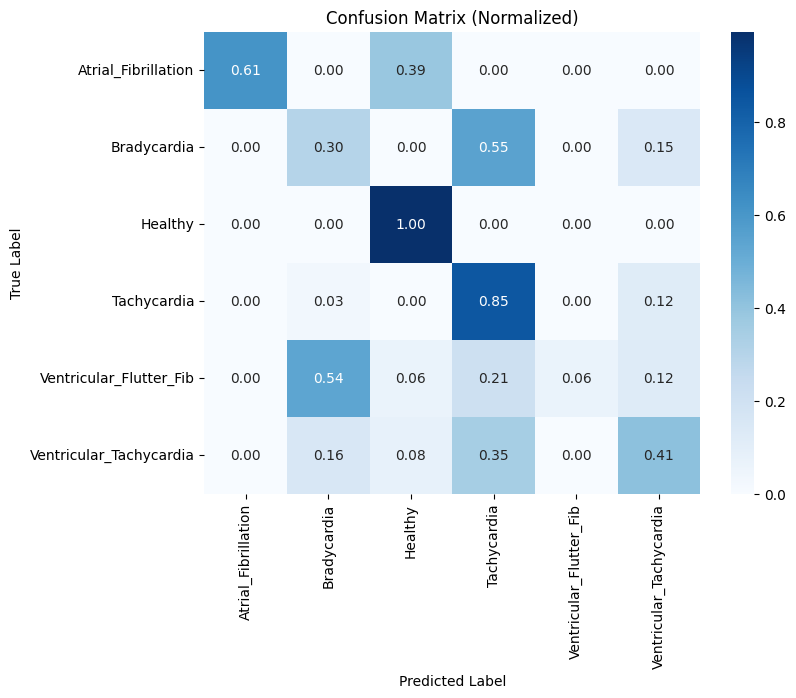


################################################################

STATUS REPORT:
Iteration 8 of 10 runs completed
Test_Score: 0.837, Best_Valid_Score: 0.859

################################################################
 


<ipython-input-22-d0c312243baa>:15: RuntimeWarning: invalid value encountered in divide
  cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


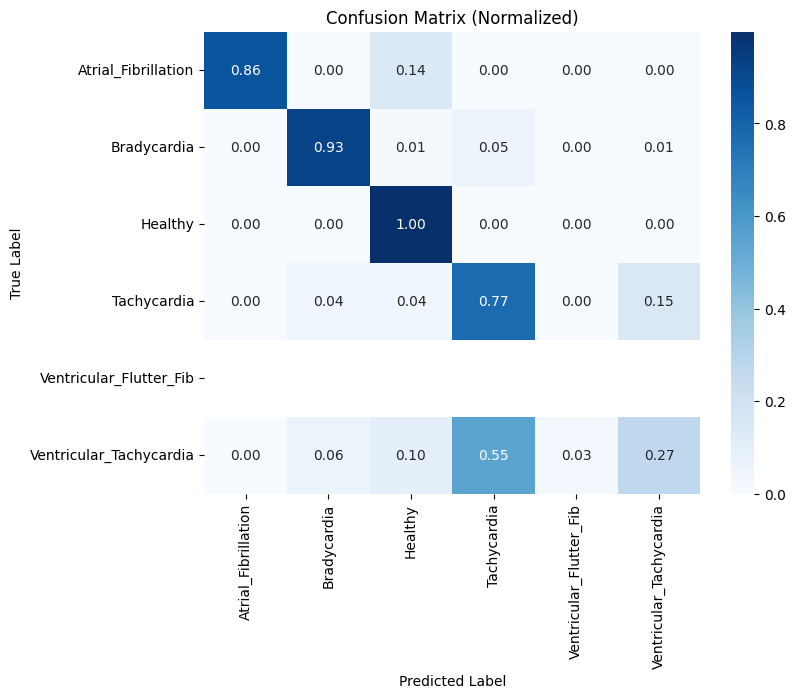


################################################################

STATUS REPORT:
Iteration 9 of 10 runs completed
Test_Score: 0.851, Best_Valid_Score: 0.859

################################################################
 


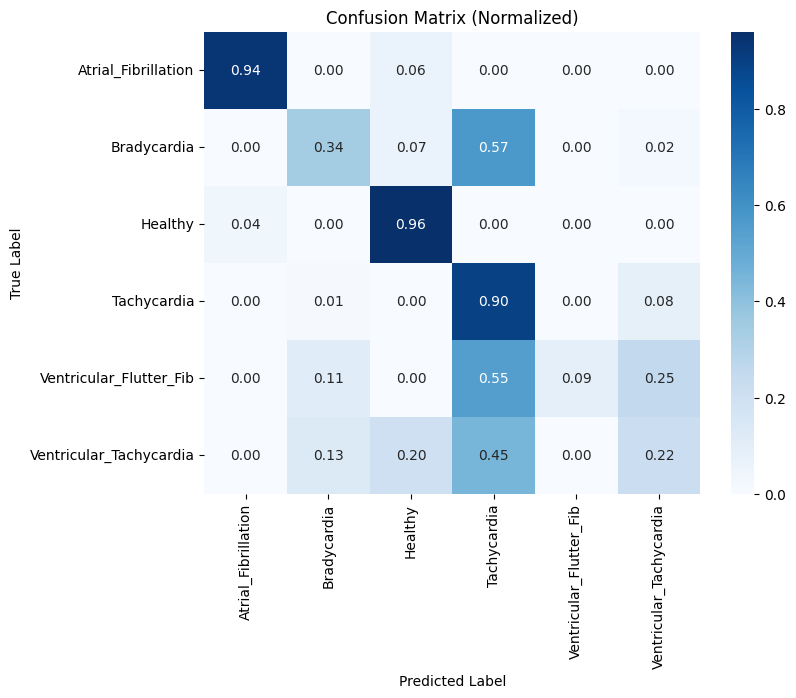


################################################################

STATUS REPORT:
Iteration 10 of 10 runs completed
Test_Score: 0.821, Best_Valid_Score: 0.859

################################################################
 


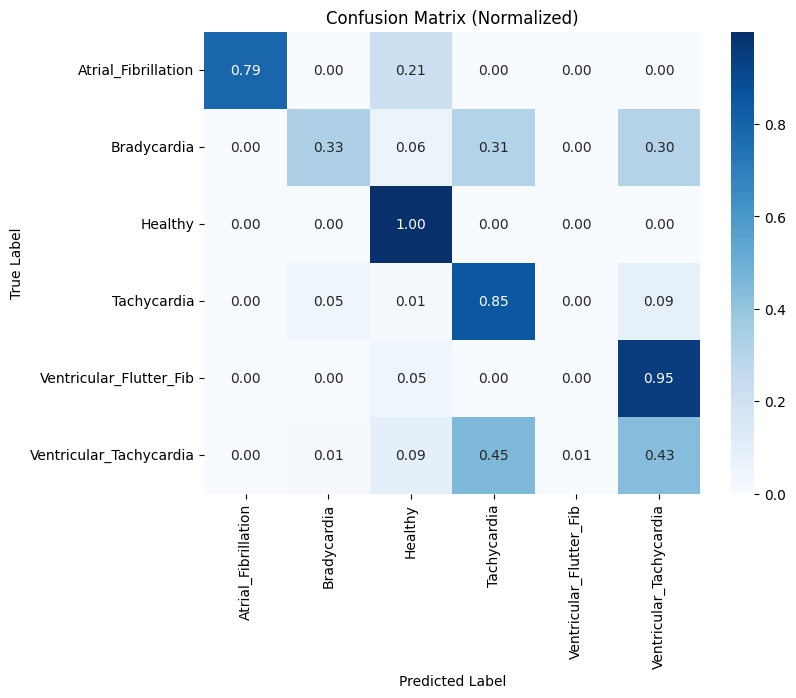

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

def plot_confusion_matrix(y_true, y_pred, class_names, normalize=True):
         # Compute confusion matrix
        cm = confusion_matrix(y_true, y_pred)

        # Normalize if needed
        if normalize:
            cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

        # Plot the heatmap
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d", cmap="Blues",
                   xticklabels=class_names, yticklabels=class_names)

        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title('Confusion Matrix' + (' (Normalized)' if normalize else ''))
        plt.show()

Xy=samples_df.drop(["Groups"], axis=1)
groups=samples_df["Groups"]

best_score=0
num_trials=10

for i in range(num_trials):
    splitter=GroupShuffleSplit(test_size=0.2, random_state=i)
    split=splitter.split(Xy, groups=groups)
    train_inds, test_inds=next(split)

    train = Xy.iloc[train_inds]
    test = Xy.iloc[test_inds]

    train_X=train.drop(["Labels"], axis=1)
    test_X=test.drop(["Labels"], axis=1)
    train_y=train["Labels"]
    test_y=test["Labels"]
    
    model=RandomForestClassifier(n_estimators=50, min_samples_split=4, min_samples_leaf=5, max_features=7,max_depth=10)
    model.fit(train_X, train_y)
    yhat=model.predict(test_X)
    acc = accuracy_score(test_y, yhat)
    
    if(acc>best_score):
        best_score=acc

    print('\n################################################################\n\nSTATUS REPORT:')
    print(f'Iteration {i + 1} of {num_trials} runs completed')
    print(f'Test_Score: {acc:.3f}, Best_Valid_Score: {best_score:.3f}')
    print("\n################################################################\n ")

    plot_confusion_matrix(test_y, yhat, class_names=model.classes_)

# Training: Stacked Model